# **Examining Occupational Stereotypes (Ngrams)**
## **Goal**: Test relationships between occupational demographics and professions' feminization–masculinization.

## **Setup**
### Imports

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

from ngramprep.common.w2v_model import W2VModel
from analyze.cosine_similarity_time_series import cosine_similarity_over_years, plot_nearest_neighbors
from analyze.weat_time_series import compute_weat_over_years
from analyze.dimension_projection_time_series import compute_projection_over_years, compute_baseline_set
from analyze.pca_dimension_time_series import compute_pca_dimension_over_years
from analyze.semantic_drift import (
    track_local_semantic_change,
    track_global_semantic_change,
    track_directional_drift,
)
from analyze.average_relatedness_by_year import track_word_relatedness
from analyze.ipums.ipums_utils import (
    aggregate_ipums_professions_csv,
    aggregate_ipums_professions_csv_batch,
    fetch_and_aggregate_ipums_professions_csv,
    fetch_ipums_microdata_cps,
    calculate_women_percentage,
    fetch_prestige_crosswalk,
    aggregate_prestige_by_label,
    add_prestige_to_panel
)
from analyze.ipums.correlation_analysis import run_correlation_analysis
from analyze.ipums.build_panel import build_panel
from ipumspy import IpumsApiClient, MicrodataExtract

import warnings
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=ConvergenceWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Configure

In [2]:
model_path =  '/scratch/edk202/NLP_models/Google_Books/20200217/eng-us/5gram_files/models_final/norm_and_align'
bin_size = 2

## **Generate gender projection**
#### Use the `compute_meandiff_dimension` method to create a masculinization dimension

In [3]:
year = 2018
model = W2VModel(f'{model_path}/w2v_y{year}_wbnone_vs300_w004_mc001_sg1_e010.kv')

gender_contrasts = [
    ('she', 'he'),
    ('her', 'his'),
    ('herself', 'himself'),
    ('woman', 'man'),
    ('women', 'men'),
    ('girl', 'boy'),
    ('girls', 'boys'),
    ('mother', 'father'),
    ('mothers', 'fathers'),
    ('daughter', 'son'),
    ('daughters', 'sons'),
    ('sister', 'brother'),
    ('sisters', 'brothers')
]

meandiff_result = model.compute_meandiff_dimension(
    token_contrasts=gender_contrasts
)

#### Print various words' projections on the masculinization dimension using the `print_word_projections` method

In [4]:
test_words = [
    # Clear anchors
    'husband', 'wife',
    'king', 'queen',

    # Historically masculine-stereotyped professions
    'engineer', 'physicist', 'soldier', 'pilot',
    'firefighter', 'mechanic', 'carpenter',
    'programmer', 'CEO', 'president',
    'construction_worker', 'plumber',

    # Historically feminine-stereotyped professions
    'nurse', 'teacher', 'secretary', 'receptionist',
    'librarian', 'babysitter', 'housekeeper',
    'caregiver', 'assistant', 'hairdresser',

    # Leadership / status roles (interesting test cases)
    'leader', 'manager', 'chairperson',
    'lawyer', 'doctor', 'scientist',
    'professor', 'judge',

    # Trait terms (useful for validating axis content)
    'strong', 'assertive', 'dominant',
    'competitive', 'logical', 'independent',
    'gentle', 'nurturing', 'empathetic',
    'emotional', 'supportive', 'caring'
]

projections = W2VModel.print_word_projections(model, meandiff_result['dimension'], test_words)


────────────────────────────────────────────────────────────────────────────────────────────────────
WORD PROJECTIONS ON DIMENSION
────────────────────────────────────────────────────────────────────────────────────────────────────
Word                           Projection                                           Visualization
────────────────────────────────────────────────────────────────────────────────────────────────────
  king                             0.1847                                               █████
  physicist                        0.1785                                               █████
  soldier                          0.1572                                                ████
  leader                           0.1492                                                ████
  president                        0.1285                                                 ███
  mechanic                         0.0844                                                  ██
  ch

## **Examine time-series**
#### Auto-generate a baseline trend using `compute_baseline_set` function

Using shared vocabulary: 29789 words found across all models

Baseline word set selection:
  Total vocabulary:          29,789
  Neutral candidates:        28,765 (after anchor & pattern exclusion)
  Selected neutral words:    24,054 (passed stability thresholds)

  Selection thresholds:
    |mu| < 0.080  (mean projection)
    |beta| < 0.0100  (trend/year)
    sigma < 0.150  (temporal variability)
    n >= 5  (minimum years)

  Neutral word statistics:
    Mean |mu|:     0.0333
    Mean |beta|:   0.0006
    Mean sigma:    0.0317

  Over-time correlation:
    Mean:          0.6038
    Median:        0.6018
    Std:           0.0660
    Range:         [0.4476, 0.7459]

  Aggregation:               mean



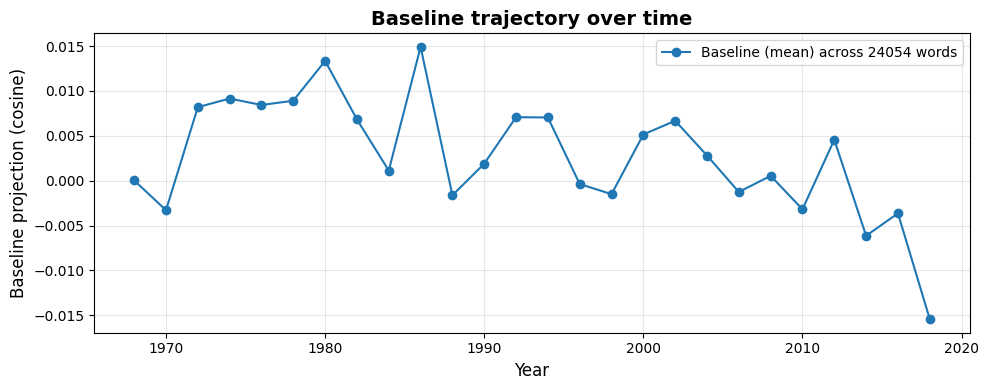

In [5]:
baseline_source = compute_baseline_set(
    model_dir=model_path,
    contrast_pairs=gender_contrasts,
    start_year=1968,
    end_year=2018,
    year_step=1,
    method='meandiff',
    exclusion_pattern=r"(man|men|woman|women|girl|boy|girls|boys|mother|father|mothers|fathers|daughter|son|daughters|sons|sister|brother)",
    eps_mean=0.08,
    eps_trend=0.010,
    eps_sigma=0.15,
    min_years=5,
    agg="mean",
    corr_n_permutations=0,
    verbose=True,
    plot_baseline=True
)

baseline_source = baseline_source["baseline"]

#### Alternatively, specify a set of baseline words

In [6]:
baseline_source = [
    'table', 'chair', 'window', 'door', 'wall', 'floor', 'roof', 'tree', 'leaf', 'branch', 'root', 'flower',
    'grass', 'water', 'stone', 'rock', 'sand', 'soil', 'clay', 'book', 'page', 'paper', 'pen', 'ink', 'cup',
    'plate', 'bowl', 'spoon', 'knife', 'fork', 'bread', 'cheese', 'butter', 'salt', 'sugar', 'road', 'path',
    'bridge', 'gate', 'fence', 'box', 'bag', 'basket', 'bottle', 'jar', 'horse', 'cow', 'sheep', 'pig',
    'chicken', 'dog', 'cat', 'sun', 'moon', 'star', 'cloud', 'rain', 'wind', 'river', 'lake', 'mountain',
    'hill', 'valley', 'wood', 'metal', 'iron', 'gold', 'silver', 'wheel', 'rope', 'chain', 'nail', 'hammer'
]

#### Specify the set of occupations from Caliskan et al. (2017)

In [7]:
targets = [
    "technician", "accountant", "supervisor", "engineer", "worker", "educator", "clerk", "counselor",
    "inspector", "mechanic", "manager", "therapist", "administrator", "salesperson", "receptionist", "librarian",
    "advisor", "pharmacist", "janitor", "psychologist", "physician", "carpenter", "nurse", "investigator",
    "bartender", "specialist", "electrician", "officer", "pathologist", "teacher", "lawyer", "planner",
    "practitioner", "plumber", "instructor", "surgeon", "veterinarian", "paramedic", "examiner", "chemist",
    "machinist", "appraiser", "nutritionist", "architect", "hairdresser", "baker", "programmer", "paralegal",
    "hygienist", "scientist"
]

#### Compute and plot masculinization time-series

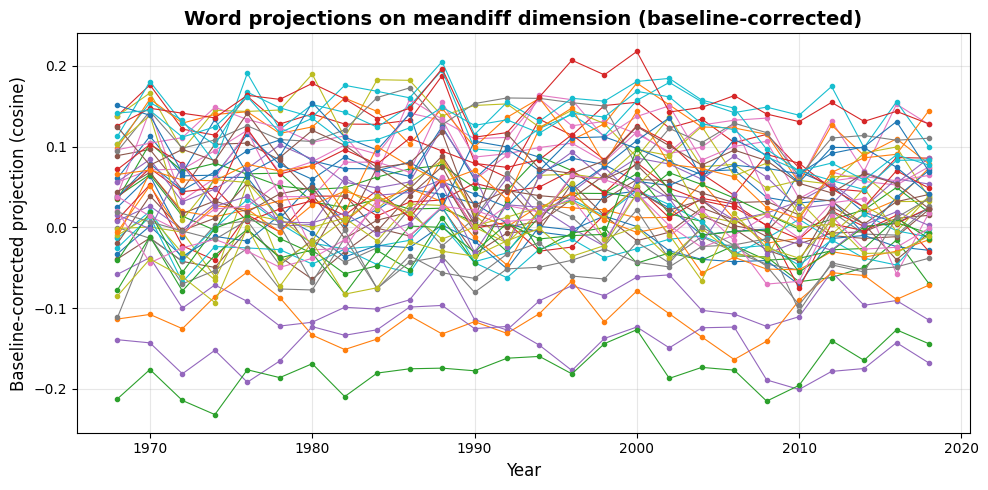

In [8]:
result = compute_projection_over_years(
    model_dir=model_path,
    token_contrasts=gender_contrasts,
    test_words=targets,
    start_year=1968,
    end_year=2018,
    year_step=2,
    method='meandiff',
    ensure_sign_positive=True,
    smooth=False,
    sigma=1,
    verbose=False,
    baseline_source=baseline_source,
    plot_corrected_if_baseline=True,
    plot=True,
 )

### **IPUMS workflow**
#### Live IPUMS CPS ASEC download

Fetches the most recent CPS ASEC extract with harmonized occupation codes (`OCC2010`) and person weights (`ASECWT`).
Auto-discovers the latest ASEC sample, submits/waits/downloads, and decompresses `.gz` files in place.

In [9]:
result_df = fetch_and_aggregate_ipums_professions_csv(
    occupation_map_file='/scratch/edk202/lexichron/ipums_occ2010_map.csv',
    api_key='59cba10d8a5da536fc06b59d0d34a8b208154b9684e7d4fadbe0a339',
    years=range(1968, 2026),
    variables=['YEAR', 'SEX', 'RACE', 'HISPAN', 'OCC2010', 'ASECWT'],
    overwrite=False,
    keep_extract_file=True,
    download_dir='/scratch/edk202/lexichron/ipums_api_downloads'
)

overwrite=False: Using 58 existing file(s) from /scratch/edk202/lexichron/ipums_api_downloads
  - professionsIPUMS_1968.csv (206 rows)
  - professionsIPUMS_1969.csv (205 rows)
  - professionsIPUMS_1970.csv (205 rows)
  ... and 55 more


In [10]:
crosswalk_df = fetch_prestige_crosswalk(
    api_key='59cba10d8a5da536fc06b59d0d34a8b208154b9684e7d4fadbe0a339',
    output_csv='/scratch/edk202/lexichron/occ2010_prestige.csv',
    download_dir='/scratch/edk202/lexichron/ipums_api_downloads'
)

prestige_df = aggregate_prestige_by_label(
    extract_file='/scratch/edk202/lexichron/ipums_api_downloads/cps_00041.csv',
    occupation_map_file='/scratch/edk202/lexichron/ipums_occ2010_map.csv',
    crosswalk_df=crosswalk_df
)

Fetching prestige crosswalk: OCCSCORE
  Duncan SEI — occupational socioeconomic index (income + education), harmonized to OCC2010
  Sample: us2019a
Submitting IPUMS USA extract...
  Extract ID: 11
Waiting for extract to complete...
  Status: completed
  Decompressed usa_00011.csv.gz -> usa_00011.csv
  Cleaned up USA extract files

  OCC2010 codes with prestige scores: 460
  Prestige range: 3.0 – 80.0
  Saved crosswalk to /scratch/edk202/lexichron/occ2010_prestige.csv
Reading extract: /scratch/edk202/lexichron/ipums_api_downloads/cps_00041.csv
  Rows: 9,714,805  |  Years: [1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  Crosswalk coverage: 4,689,439 / 9,714,805 rows matched (48.3%)

  Label

In [11]:
panel_df = build_panel(
    result=result,
    result_df=result_df,
    targets=targets,
    calculate_women_percentage=calculate_women_percentage,
    use_baseline_corrected_panel=True,
    bin_size=bin_size
)

In [12]:
prestige_df.to_csv('/scratch/edk202/lexichron/prestige_by_label.csv', index=False)
panel_df = add_prestige_to_panel(panel_df, prestige_df)

In [13]:
profession_means = panel_df.groupby('profession')[['prestige', 'projection', 'women_pct']].mean()
profession_means.corr()

,prestige,projection,women_pct
prestige,1.000000,0.350401,-0.480396
projection,0.350401,1.000000,-0.672983
women_pct,-0.480396,-0.672983,1.000000


Using IPUMS data: /scratch/edk202/lexichron/ipums_api_downloads/professionsIPUMS_1968.csv
Matched 37/50 professions in IPUMS data
Using baseline-corrected projections
Valid professions (non-NaN projections): 37 out of 37
Filtered out 0 professions with NaN projections

=== Correlation Results (Baseline-corrected) ===
Pearson r = -0.6943
p-value = 0.000002
n = 37 professions


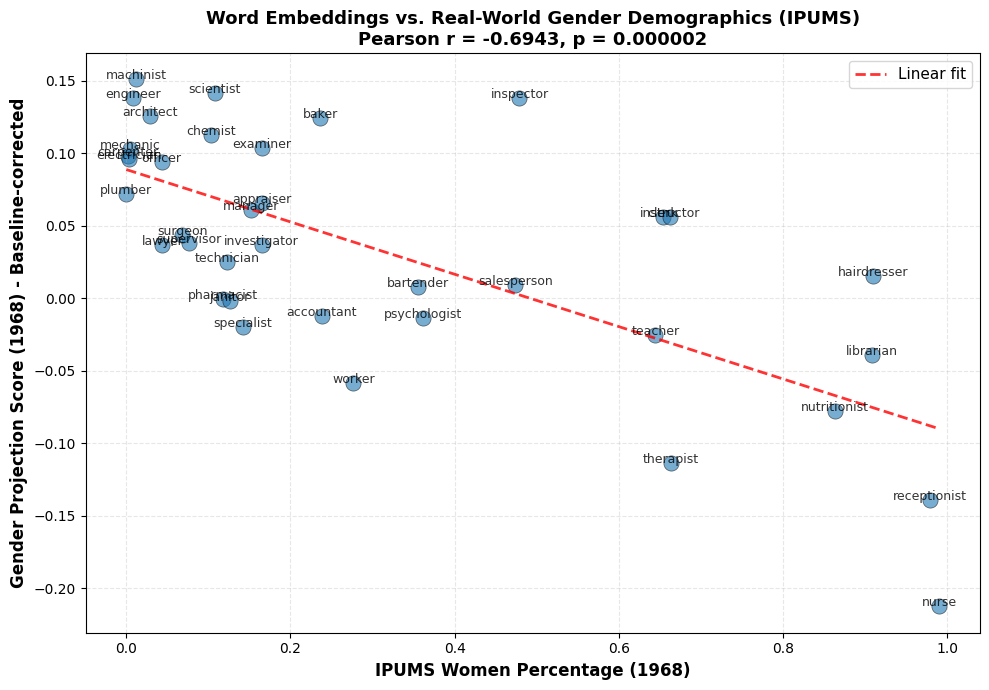


✓ Significant correlation (p < 0.05)


In [14]:
run_correlation_analysis(
    year_of_interest=1968,
    use_baseline_corrected=True,
    targets=targets,
    result_df=result_df,
    result=result,
    calculate_women_percentage=calculate_women_percentage
)

## RI-CLPM Lag Sweep: Trend Adjustment Comparison

This cell estimates cross-lagged panel models across lags 1–20, comparing four approaches to secular trend adjustment:

| Method | Description |
|--------|-------------|
| **No adjustment** | Baseline model; estimates total covariance between W% and projection over time |
| **Linear trend** | Adds a single time trend term; assumes smooth, monotonic secular change |
| **Quadratic trend** | Adds linear + quadratic terms; allows curvature in the secular trend |
| **Year FE** | Adds a dummy for each calendar year (`C(year)`); fully nonparametric, absorbs all shared period effects |

For each lag *k* and each trend specification, two models are estimated:
- **W%(t−k) → Projection(t)**: Does past demographic composition predict current semantic gender?
- **Projection(t−k) → W%(t)**: Does past semantic gender predict current demographic composition?

Both models include the lagged dependent variable as a covariate (RI-CLPM structure).

### Multiple comparison correction
P-values are corrected across lags separately for each direction using the method specified in `correction_method`. Options:

| Value | Method |
|-------|--------|
| `None` | No correction |
| `'bonferroni'` | Bonferroni (conservative) |
| `'holm'` | Holm-Bonferroni (less conservative) |
| `'fdr_bh'` | Benjamini-Hochberg FDR (default) |
| `'fdr_by'` | Benjamini-Yekutieli FDR (more conservative) |

### Key parameters
```python
lag_range = range(1, 21)
alpha = 0.05
correction_method = 'fdr_bh'
```

### Output
- **Top panels**: β coefficients across lags for each trend specification
- **Bottom panels**: Adjusted p-values (log scale) with α = 0.05 reference line
- **Summary table**: Significant lags per method and direction
- **Detailed table**: Full results for the Year FE model

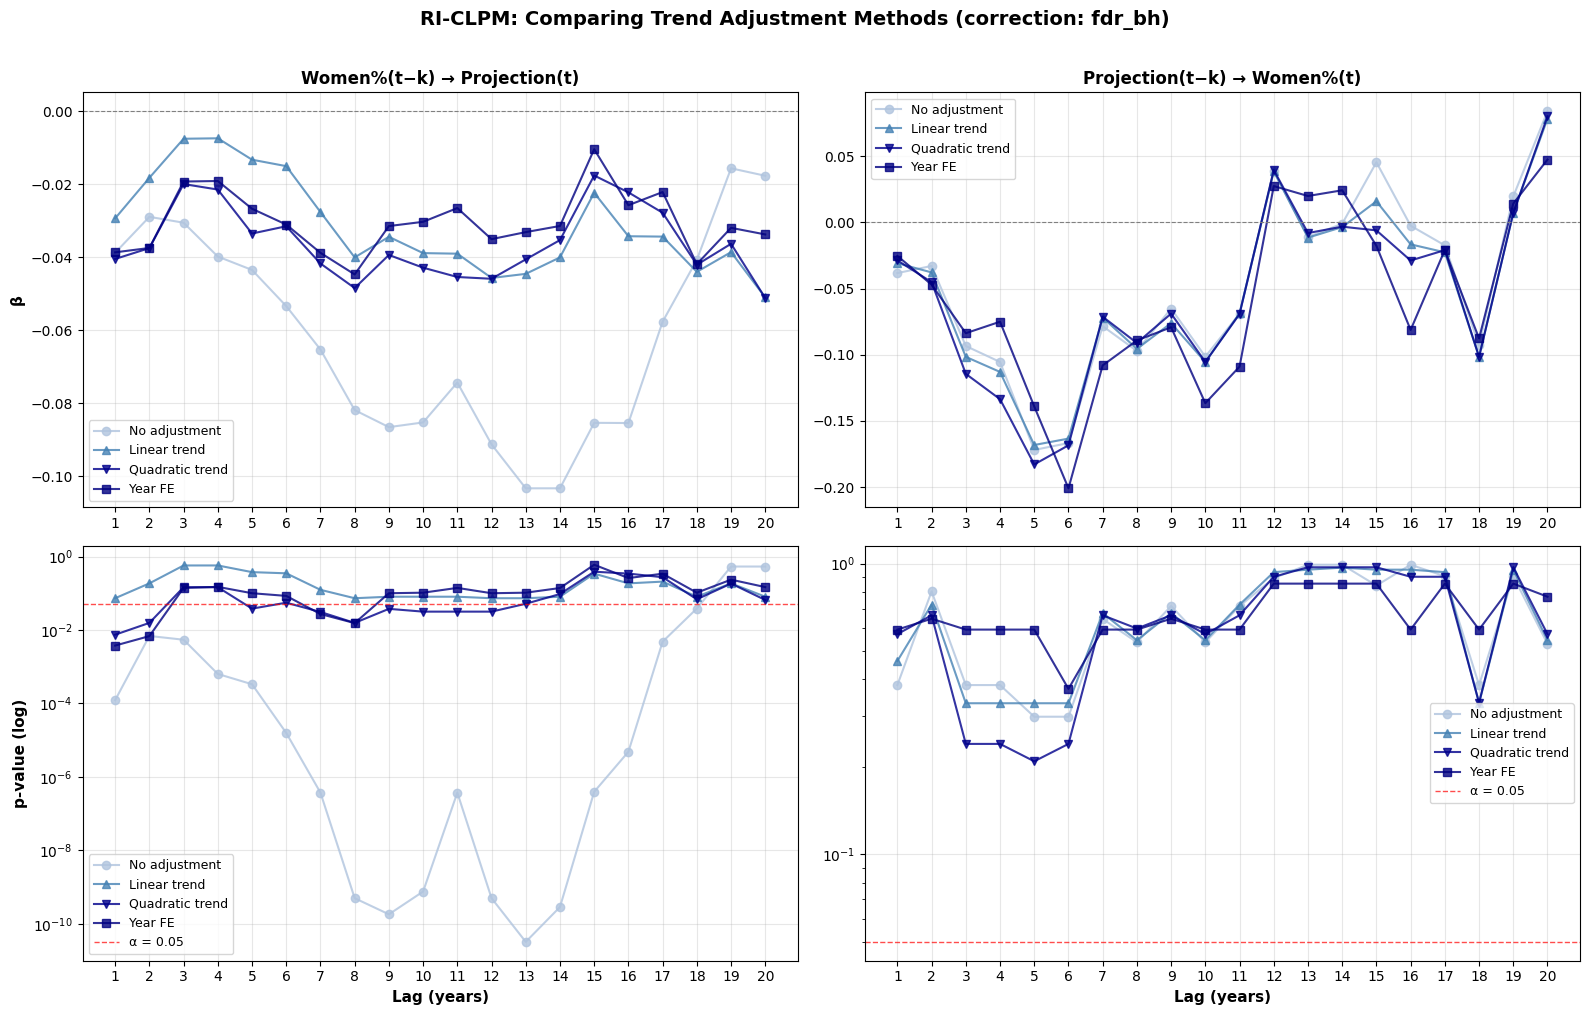


SUMMARY: Significant lags (adjusted p < 0.05) | Correction: fdr_bh
No adjustment       : W→P sig at 18/20 lags [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
                      P→W sig at  0/20 lags []
Linear trend        : W→P sig at  0/20 lags []
                      P→W sig at  0/20 lags []
Quadratic trend     : W→P sig at  9/20 lags [1, 2, 5, 7, 8, 9, 10, 11, 12]
                      P→W sig at  0/20 lags []
Year FE             : W→P sig at  4/20 lags [1, 2, 7, 8]
                      P→W sig at  0/20 lags []

------------------------------------------------------------------------------------------
YEAR FE MODEL DETAILS (correction: fdr_bh)
------------------------------------------------------------------------------------------
 Lag     n     β(W→P)    p_raw    p_adj  sig     β(P→W)    p_raw    p_adj  sig
──────────────────────────────────────────────────────────────────────────────────────────
   1  1073   -0.03866   0.0002   0.0038    ✓   -0.02534   0.2

In [15]:
lag_range = range(1, 21)
alpha = 0.05
correction_method = 'fdr_bh'

results = {'none': [], 'year_fe': [], 'linear': [], 'quadratic': []}

panel_sorted = panel_df.sort_values(['profession', 'year']).copy()
panel_sorted['time_trend'] = panel_sorted['year'] - panel_sorted['year'].min()
panel_sorted['time_trend_sq'] = panel_sorted['time_trend'] ** 2

for lag_k in lag_range:
    panel_sorted[f'women_pct_lag{lag_k}'] = panel_sorted.groupby('profession')['women_pct'].shift(lag_k)
    panel_sorted[f'projection_lag{lag_k}'] = panel_sorted.groupby('profession')['projection'].shift(lag_k)

for lag_k in lag_range:
    wp_lag   = f'women_pct_lag{lag_k}'
    proj_lag = f'projection_lag{lag_k}'

    df_k = panel_sorted.dropna(subset=[wp_lag, proj_lag]).copy()
    if len(df_k) < 20:
        continue

    formulas = {
        'none': (
            f"projection ~ {proj_lag} + {wp_lag}",
            f"women_pct ~ {wp_lag} + {proj_lag}"
        ),
        'year_fe': (
            f"projection ~ {proj_lag} + {wp_lag} + C(year)",
            f"women_pct ~ {wp_lag} + {proj_lag} + C(year)"
        ),
        'linear': (
            f"projection ~ {proj_lag} + {wp_lag} + time_trend",
            f"women_pct ~ {wp_lag} + {proj_lag} + time_trend"
        ),
        'quadratic': (
            f"projection ~ {proj_lag} + {wp_lag} + time_trend + time_trend_sq",
            f"women_pct ~ {wp_lag} + {proj_lag} + time_trend + time_trend_sq"
        ),
    }

    for model_type, (f1, f2) in formulas.items():
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                m1 = smf.mixedlm(f1, data=df_k, groups=df_k["profession"]).fit(disp=False)
                m2 = smf.mixedlm(f2, data=df_k, groups=df_k["profession"]).fit(disp=False)

            results[model_type].append({
                'lag':      lag_k,
                'n_obs':    len(df_k),
                'beta_w2p': m1.fe_params[wp_lag],
                'se_w2p':   m1.bse[wp_lag],
                'p_w2p':    m1.pvalues[wp_lag],
                'beta_p2w': m2.fe_params[proj_lag],
                'se_p2w':   m2.bse[proj_lag],
                'p_p2w':    m2.pvalues[proj_lag],
            })
        except Exception as e:
            print(f"  Lag {lag_k}, {model_type}: failed ({e})")

result_dfs = {}
for k, v in results.items():
    df = pd.DataFrame(v)
    if not df.empty and correction_method is not None:
        _, p_w2p_adj, _, _ = multipletests(df['p_w2p'], alpha=alpha, method=correction_method)
        df['p_w2p_adj'] = p_w2p_adj
        df['sig_w2p']   = p_w2p_adj < alpha

        _, p_p2w_adj, _, _ = multipletests(df['p_p2w'], alpha=alpha, method=correction_method)
        df['p_p2w_adj'] = p_p2w_adj
        df['sig_p2w']   = p_p2w_adj < alpha
    elif not df.empty:
        df['p_w2p_adj'] = df['p_w2p']
        df['p_p2w_adj'] = df['p_p2w']
        df['sig_w2p']   = df['p_w2p'] < alpha
        df['sig_p2w']   = df['p_p2w'] < alpha
    result_dfs[k] = df

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = {
    'none':      ('lightsteelblue', 'o', 'No adjustment'),
    'linear':    ('steelblue',      '^', 'Linear trend'),
    'quadratic': ('darkblue',       'v', 'Quadratic trend'),
    'year_fe':   ('navy',           's', 'Year FE'),
}

p_col_w2p = 'p_w2p_adj'
p_col_p2w = 'p_p2w_adj'

ax = axes[0, 0]
for model_type, (color, marker, label) in colors.items():
    df = result_dfs[model_type]
    if not df.empty:
        ax.plot(df['lag'], df['beta_w2p'], f'{marker}-', color=color, label=label, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('β', fontsize=11, fontweight='bold')
ax.set_title('Women%(t−k) → Projection(t)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for model_type, (color, marker, label) in colors.items():
    df = result_dfs[model_type]
    if not df.empty:
        ax.plot(df['lag'], df['beta_p2w'], f'{marker}-', color=color, label=label, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Projection(t−k) → Women%(t)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for model_type, (color, marker, label) in colors.items():
    df = result_dfs[model_type]
    if not df.empty:
        ax.plot(df['lag'], df[p_col_w2p], f'{marker}-', color=color, label=label, alpha=0.8)
ax.axhline(alpha, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'α = {alpha}')
ax.set_yscale('log')
ax.set_ylabel('p-value (log)', fontsize=11, fontweight='bold')
ax.set_xlabel('Lag (years)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for model_type, (color, marker, label) in colors.items():
    df = result_dfs[model_type]
    if not df.empty:
        ax.plot(df['lag'], df[p_col_p2w], f'{marker}-', color=color, label=label, alpha=0.8)
ax.axhline(alpha, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'α = {alpha}')
ax.set_yscale('log')
ax.set_xlabel('Lag (years)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for ax_row in axes:
    for ax in ax_row:
        if not result_dfs['none'].empty:
            ax.set_xticks(result_dfs['none']['lag'])

correction_label = correction_method if correction_method else 'None'
fig.suptitle(f'RI-CLPM: Comparing Trend Adjustment Methods (correction: {correction_label})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print(f"SUMMARY: Significant lags (adjusted p < {alpha}) | Correction: {correction_label}")
print("=" * 90)

for model_type, label in [('none', 'No adjustment'), ('linear', 'Linear trend'),
                           ('quadratic', 'Quadratic trend'), ('year_fe', 'Year FE')]:
    df = result_dfs[model_type]
    if df.empty:
        continue
    sig_w2p_lags = df.loc[df['sig_w2p'], 'lag'].tolist()
    sig_p2w_lags = df.loc[df['sig_p2w'], 'lag'].tolist()
    print(f"{label:<20}: W→P sig at {df['sig_w2p'].sum():>2}/{len(df)} lags {sig_w2p_lags}")
    print(f"{'':<20}  P→W sig at {df['sig_p2w'].sum():>2}/{len(df)} lags {sig_p2w_lags}")

print("\n" + "-" * 90)
print(f"YEAR FE MODEL DETAILS (correction: {correction_label})")
print("-" * 90)
yfe_df = result_dfs['year_fe']
if not yfe_df.empty:
    print(f"{'Lag':>4} {'n':>5}  {'β(W→P)':>9} {'p_raw':>8} {'p_adj':>8} {'sig':>4}  "
          f"{'β(P→W)':>9} {'p_raw':>8} {'p_adj':>8} {'sig':>4}")
    print("─" * 90)
    for _, row in yfe_df.iterrows():
        print(f"{int(row['lag']):>4} {int(row['n_obs']):>5}  "
              f"{row['beta_w2p']:>+9.5f} {row['p_w2p']:>8.4f} {row['p_w2p_adj']:>8.4f} {'✓' if row['sig_w2p'] else '':>4}  "
              f"{row['beta_p2w']:>+9.5f} {row['p_p2w']:>8.4f} {row['p_p2w_adj']:>8.4f} {'✓' if row['sig_p2w'] else '':>4}")

In [16]:
print("=" * 70)
print("RI-CLPM HETEROGENEITY TEST: Does prestige moderate the W% → Projection effect?")
print("=" * 70)

# --- Parameters ---
TREND_ADJUSTMENT  = 'year_fe'
CORRECTION_METHOD = 'fdr_bh'
ALPHA             = 0.05

# Use prestige_z as moderator (already on panel_df from add_prestige_to_panel)
panel_het = panel_df.copy()

# Center year
year_mean = panel_het['year'].mean()
panel_het['year_c']  = panel_het['year'] - year_mean
panel_het['year_c2'] = panel_het['year_c'] ** 2

panel_het = panel_het.sort_values(['profession', 'year']).copy()

test_lags = list(range(1, 20))

def trend_term(adjustment):
    if adjustment == 'none':      return ''
    elif adjustment == 'linear':  return '+ year_c'
    elif adjustment == 'quadratic': return '+ year_c + year_c2'
    elif adjustment == 'year_fe': return '+ C(year)'
    else: raise ValueError(f"Unknown trend adjustment: {adjustment}")

trend = trend_term(TREND_ADJUSTMENT)
print(f"Trend adjustment:  {TREND_ADJUSTMENT}")
print(f"MCC method:        {CORRECTION_METHOD}")

results_het   = []
Z_VALS = [-1, 0, 1]
simple_slopes = {z: [] for z in Z_VALS}

for lag_k in test_lags:
    panel_het[f'women_pct_lag{lag_k}']   = panel_het.groupby('profession')['women_pct'].shift(lag_k)
    panel_het[f'projection_lag{lag_k}']  = panel_het.groupby('profession')['projection'].shift(lag_k)
    panel_het[f'wp_lag{lag_k}_x_prest']  = panel_het[f'women_pct_lag{lag_k}'] * panel_het['prestige_z']

    df_k = panel_het.dropna(subset=[f'women_pct_lag{lag_k}', f'projection_lag{lag_k}', 'prestige_z']).copy()

    if len(df_k) < 50:
        for z in Z_VALS:
            simple_slopes[z].append({'lag': lag_k, 'beta': np.nan, 'se': np.nan, 'p': np.nan})
        continue

    formula_main = f"projection ~ projection_lag{lag_k} + women_pct_lag{lag_k} {trend}"
    formula_het  = (
        f"projection ~ projection_lag{lag_k} + women_pct_lag{lag_k} "
        f"+ wp_lag{lag_k}_x_prest {trend}"
    )

    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            result_main = smf.mixedlm(formula_main, data=df_k, groups=df_k["profession"]).fit(disp=False)
            result_het  = smf.mixedlm(formula_het,  data=df_k, groups=df_k["profession"]).fit(disp=False)

        beta_main = result_main.fe_params[f'women_pct_lag{lag_k}']
        p_main    = result_main.pvalues[f'women_pct_lag{lag_k}']
        beta_wp   = result_het.fe_params[f'women_pct_lag{lag_k}']
        beta_int  = result_het.fe_params[f'wp_lag{lag_k}_x_prest']
        p_wp      = result_het.pvalues[f'women_pct_lag{lag_k}']
        p_int     = result_het.pvalues[f'wp_lag{lag_k}_x_prest']

        cov        = result_het.cov_params()
        var_wp     = cov.loc[f'women_pct_lag{lag_k}',   f'women_pct_lag{lag_k}']
        var_int    = cov.loc[f'wp_lag{lag_k}_x_prest',  f'wp_lag{lag_k}_x_prest']
        cov_wp_int = cov.loc[f'women_pct_lag{lag_k}',   f'wp_lag{lag_k}_x_prest']
        df_resid   = len(df_k) - len(result_het.fe_params)

        for z in Z_VALS:
            implied_beta = beta_wp + beta_int * z
            implied_se   = np.sqrt(var_wp + z**2 * var_int + 2 * z * cov_wp_int)
            t_stat       = implied_beta / implied_se
            p_val        = 2 * stats.t.sf(abs(t_stat), df=df_resid)
            simple_slopes[z].append({
                'lag':  lag_k,
                'beta': implied_beta,
                'se':   implied_se,
                'p':    p_val,
            })

        results_het.append({
            'lag':       lag_k,
            'n':         len(df_k),
            'beta_main': beta_main,
            'p_main':    p_main,
            'beta_wp':   beta_wp,
            'p_wp':      p_wp,
            'beta_int':  beta_int,
            'p_int':     p_int,
        })

        print(f"\n{'─' * 70}")
        print(f"Lag {lag_k} (n = {len(df_k)})  [{TREND_ADJUSTMENT}]")
        print(f"{'─' * 70}")
        print(f"\n  Main effects model:")
        print(f"    β(W%_lag{lag_k}): {beta_main:+.5f} (p = {p_main:.4f})")
        print(f"\n  Heterogeneous effects model:")
        print(f"    β(W%_lag{lag_k}):              {beta_wp:+.5f} (p = {p_wp:.4f})")
        print(f"    β(W%_lag{lag_k} × prestige_z): {beta_int:+.5f} (p = {p_int:.4f})")
        print(f"\n  Simple slopes (proper SE, raw p):")
        for z, label in [(-1, "Low prestige (-1 SD)"), (0, "Average prestige"), (1, "High prestige (+1 SD)")]:
            ss = simple_slopes[z][-1]
            print(f"    {label:<24}: β = {ss['beta']:+.5f}  SE = {ss['se']:.5f}  p = {ss['p']:.4f}")
        if p_int < 0.05:
            print(f"\n  ✓ Significant heterogeneity (p = {p_int:.4f})")
        else:
            print(f"\n  ✗ No significant heterogeneity (p = {p_int:.4f})")

    except Exception as e:
        print(f"  Lag {lag_k}: failed ({e})")
        for z in Z_VALS:
            simple_slopes[z].append({'lag': lag_k, 'beta': np.nan, 'se': np.nan, 'p': np.nan})

# ── Multiple comparison correction ───────────────────────────────────────────
def apply_correction(p_series, method, alpha):
    if method is None:
        return p_series.copy()
    valid = p_series.notna()
    result = p_series.copy()
    _, p_adj, _, _ = multipletests(p_series[valid], alpha=alpha, method=method)
    result[valid] = p_adj
    return result

if results_het:
    results_df = pd.DataFrame(results_het)
    results_df['p_main_adj'] = apply_correction(results_df['p_main'], CORRECTION_METHOD, ALPHA)
    results_df['p_int_adj']  = apply_correction(results_df['p_int'],  CORRECTION_METHOD, ALPHA)

for z in Z_VALS:
    ss_df = pd.DataFrame(simple_slopes[z])
    ss_df['p_adj'] = apply_correction(ss_df['p'], CORRECTION_METHOD, ALPHA)
    simple_slopes[z] = ss_df.to_dict('records')

# ── Significance color helper ─────────────────────────────────────────────────
def sig_color(p, base_color, light_color, alpha=ALPHA):
    return base_color if p < alpha else light_color

# ── Visualization 1: main effect + interaction overview ──────────────────────
if results_het:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    bar_colors = [sig_color(p, 'steelblue', 'lightsteelblue') for p in results_df['p_main_adj']]
    ax.bar(results_df['lag'], results_df['beta_main'], color=bar_colors, alpha=0.9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Lag', fontsize=11, fontweight='bold')
    ax.set_ylabel('β (W% → Projection)', fontsize=11, fontweight='bold')
    ax.set_title(f'Main Effect [{TREND_ADJUSTMENT}]', fontsize=12, fontweight='bold')
    ax.set_xticks(results_df['lag'])
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(handles=[
        Patch(facecolor='steelblue',      alpha=0.9, label='p < .05 (adj.)'),
        Patch(facecolor='lightsteelblue', alpha=0.9, label='p ≥ .05 (adj.)'),
    ], fontsize=9)

    ax = axes[1]
    width = 0.25
    x = np.arange(len(results_df))
    base_colors  = {-1: 'coral',     0: 'gray',      1: 'steelblue'}
    light_colors = {-1: 'mistyrose', 0: 'lightgray', 1: 'lightsteelblue'}
    for i, (z, label) in enumerate([(-1, 'Low prestige'), (0, 'Average'), (1, 'High prestige')]):
        implied    = results_df['beta_wp'] + results_df['beta_int'] * z
        bar_colors = [
            sig_color(row['p_int_adj'], base_colors[z], light_colors[z])
            for _, row in results_df.iterrows()
        ]
        ax.bar(x + (i - 1) * width, implied, width=width, color=bar_colors, alpha=0.9, label=label)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Lag', fontsize=11, fontweight='bold')
    ax.set_ylabel('Implied β', fontsize=11, fontweight='bold')
    ax.set_title(
        f'Effect by Prestige [{TREND_ADJUSTMENT}]\n'
        f'(color = interaction significance, {CORRECTION_METHOD} adj.)',
        fontsize=12, fontweight='bold'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['lag'])
    ax.legend(title='Prestige', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

# ── Visualization 2: separate panels with proper simple slope SEs ─────────────
baseline_specs = [
    (-1, 'coral',     'mistyrose',      'Low-Prestige Occupations'),
    ( 0, 'gray',      'lightgray',      'Average-Prestige Occupations'),
    ( 1, 'steelblue', 'lightsteelblue', 'High-Prestige Occupations'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (z, color, light, title) in zip(axes, baseline_specs):
    ss = pd.DataFrame(simple_slopes[z]).dropna(subset=['beta', 'se', 'p'])

    bar_colors = [sig_color(p, color, light) for p in ss['p_adj']]
    ax.bar(ss['lag'], ss['beta'], color=bar_colors, alpha=0.9, width=0.7)
    ax.errorbar(ss['lag'], ss['beta'],
                yerr=1.96 * ss['se'],
                fmt='none', color='black', capsize=3, linewidth=0.8, alpha=0.6)

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Lag', fontsize=11, fontweight='bold')
    if ax == axes[0]:
        ax.set_ylabel('Simple Slope β (W% → Projection)', fontsize=11, fontweight='bold')
    ax.set_xticks(ss['lag'])
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(handles=[
        Patch(facecolor=color, alpha=0.9, label='p < .05 (adj.)'),
        Patch(facecolor=light, alpha=0.9, label='p ≥ .05 (adj.)'),
    ], fontsize=9, loc='lower left')

fig.suptitle(
    f'Simple Slopes: W% → Projection by Occupational Prestige [{TREND_ADJUSTMENT}]\n'
    f'(error bars = ±1.96 SE; color = simple slope significance, {CORRECTION_METHOD} adj.)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(f"""
Trend adjustment:  {TREND_ADJUSTMENT}
Correction method: {CORRECTION_METHOD}
Moderator:         prestige_z (Duncan OCCSCORE, z-scored across labels)

Simple slope SE = sqrt(Var(β_wp) + z²·Var(β_int) + 2z·Cov(β_wp, β_int))

If β_interaction > 0:
  → Effect is MORE POSITIVE (less negative) for high-prestige occupations
  → demographic feminization has SMALLER feminizing effect on
    high-prestige occupations (status buffering)

If β_interaction < 0:
  → Effect is MORE NEGATIVE for high-prestige occupations
  → demographic feminization has LARGER feminizing effect on
    high-prestige occupations
""")

RI-CLPM HETEROGENEITY TEST: Does prestige moderate the W% → Projection effect?
Trend adjustment:  year_fe
MCC method:        fdr_bh
  Lag 1: failed (name 'stats' is not defined)
  Lag 2: failed (name 'stats' is not defined)
  Lag 3: failed (name 'stats' is not defined)
  Lag 4: failed (name 'stats' is not defined)
  Lag 5: failed (name 'stats' is not defined)
  Lag 6: failed (name 'stats' is not defined)
  Lag 7: failed (name 'stats' is not defined)
  Lag 8: failed (name 'stats' is not defined)
  Lag 9: failed (name 'stats' is not defined)
  Lag 10: failed (name 'stats' is not defined)
  Lag 11: failed (name 'stats' is not defined)
  Lag 12: failed (name 'stats' is not defined)
  Lag 13: failed (name 'stats' is not defined)
  Lag 14: failed (name 'stats' is not defined)
  Lag 15: failed (name 'stats' is not defined)
  Lag 16: failed (name 'stats' is not defined)
  Lag 17: failed (name 'stats' is not defined)
  Lag 18: failed (name 'stats' is not defined)
  Lag 19: failed (name 'stats' 

ZeroDivisionError: float division by zero

RI-CLPM JOINT MODERATION: baseline_proj_z AND prestige_z
Trend adjustment:  year_fe
MCC method:        fdr_bh

──────────────────────────────────────────────────────────────────────
Lag 1 (n = 999)  [year_fe]
──────────────────────────────────────────────────────────────────────
  Moderator                     β (alone)  p (alone)   β (joint)  p (joint)
  ────────────────────────────────────────────────────────────────────────
  baseline_proj_z                +0.04496     0.0000    +0.04512     0.0000
  prestige_z                     +0.01806     0.0208    -0.00030     0.9651

──────────────────────────────────────────────────────────────────────
Lag 2 (n = 957)  [year_fe]
──────────────────────────────────────────────────────────────────────
  Moderator                     β (alone)  p (alone)   β (joint)  p (joint)
  ────────────────────────────────────────────────────────────────────────
  baseline_proj_z                +0.04873     0.0000    +0.04900     0.0000
  prestige_z        

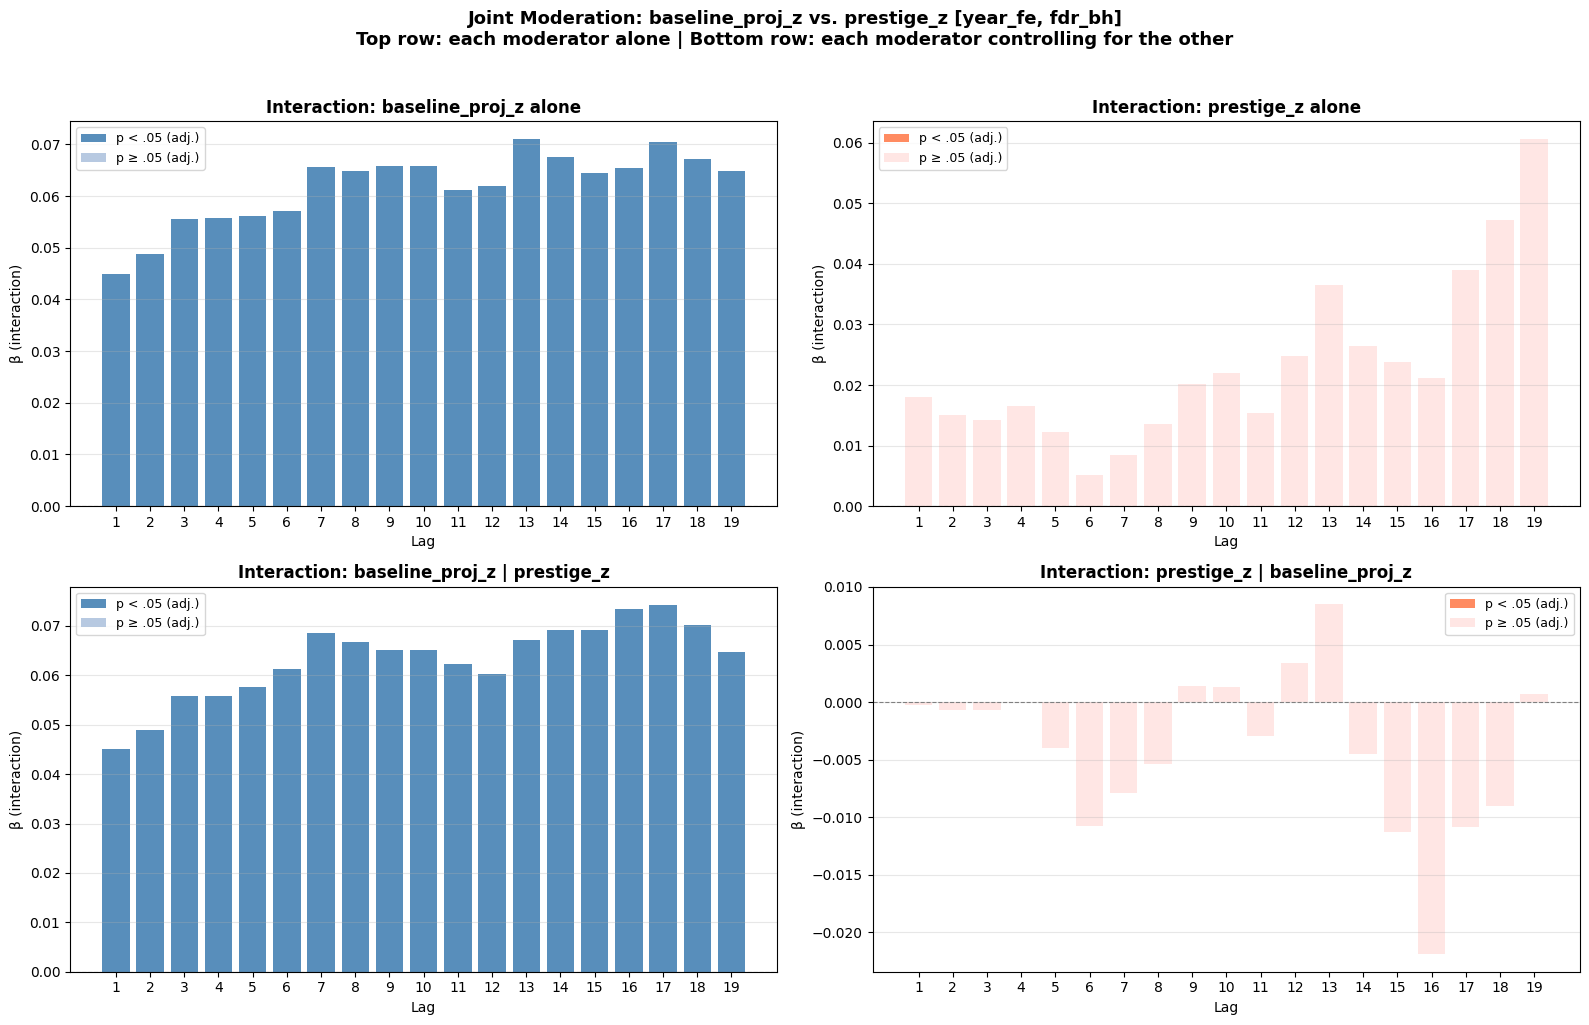


SUMMARY TABLE  [year_fe, fdr_bh adj.]
 Lag     n   β_base(alone)    padj  β_prest(alone)    padj   β_base(joint)    padj  β_prest(joint)    padj
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1   999        +0.04496 0.0000✓        +0.01806 0.1787         +0.04512 0.0000✓        -0.00030 0.9974 
   2   957        +0.04873 0.0000✓        +0.01502 0.2462         +0.04900 0.0000✓        -0.00068 0.9974 
   3   915        +0.05557 0.0000✓        +0.01421 0.2462         +0.05585 0.0000✓        -0.00073 0.9974 
   4   873        +0.05574 0.0000✓        +0.01651 0.2462         +0.05573 0.0000✓        -0.00003 0.9974 
   5   831        +0.05610 0.0000✓        +0.01221 0.3663         +0.05767 0.0000✓        -0.00400 0.9974 
   6   789        +0.05704 0.0000✓        +0.00506 0.6713         +0.06120 0.0000✓        -0.01076 0.9974 
   7   747        +0.06554 0.0000✓        +0.00844 0.5383         +0.06866 0.0000✓        -0.00794 0.

In [ ]:
print("=" * 70)
print("RI-CLPM JOINT MODERATION: baseline_proj_z AND prestige_z")
print("=" * 70)

# --- Parameters ---
TREND_ADJUSTMENT  = 'year_fe'
CORRECTION_METHOD = 'fdr_bh'
ALPHA             = 0.05

# Compute baseline_proj_z if not already on panel_het
prof_baseline = panel_df.groupby('profession')['projection'].mean()
panel_het = panel_df.copy()
panel_het['baseline_proj'] = panel_het['profession'].map(prof_baseline)
panel_het['baseline_proj_z'] = (
    (panel_het['baseline_proj'] - panel_het['baseline_proj'].mean())
    / panel_het['baseline_proj'].std()
)

year_mean = panel_het['year'].mean()
panel_het['year_c']  = panel_het['year'] - year_mean
panel_het['year_c2'] = panel_het['year_c'] ** 2
panel_het = panel_het.sort_values(['profession', 'year']).copy()

test_lags = list(range(1, 20))

def trend_term(adjustment):
    if adjustment == 'none':        return ''
    elif adjustment == 'linear':    return '+ year_c'
    elif adjustment == 'quadratic': return '+ year_c + year_c2'
    elif adjustment == 'year_fe':   return '+ C(year)'
    else: raise ValueError(f"Unknown trend adjustment: {adjustment}")

trend = trend_term(TREND_ADJUSTMENT)
print(f"Trend adjustment:  {TREND_ADJUSTMENT}")
print(f"MCC method:        {CORRECTION_METHOD}")

results_joint = []

for lag_k in test_lags:
    panel_het[f'women_pct_lag{lag_k}']      = panel_het.groupby('profession')['women_pct'].shift(lag_k)
    panel_het[f'projection_lag{lag_k}']     = panel_het.groupby('profession')['projection'].shift(lag_k)
    panel_het[f'wp_lag{lag_k}_x_base']      = panel_het[f'women_pct_lag{lag_k}'] * panel_het['baseline_proj_z']
    panel_het[f'wp_lag{lag_k}_x_prest']     = panel_het[f'women_pct_lag{lag_k}'] * panel_het['prestige_z']

    df_k = panel_het.dropna(subset=[
        f'women_pct_lag{lag_k}', f'projection_lag{lag_k}',
        'baseline_proj_z', 'prestige_z'
    ]).copy()

    if len(df_k) < 50:
        results_joint.append({
            'lag': lag_k, 'n': len(df_k),
            'beta_wp': np.nan, 'p_wp': np.nan,
            'beta_base': np.nan, 'p_base': np.nan,
            'beta_prest': np.nan, 'p_prest': np.nan,
        })
        continue

    # Model 1: baseline only
    formula_base = (
        f"projection ~ projection_lag{lag_k} + women_pct_lag{lag_k} "
        f"+ wp_lag{lag_k}_x_base {trend}"
    )
    # Model 2: prestige only
    formula_prest = (
        f"projection ~ projection_lag{lag_k} + women_pct_lag{lag_k} "
        f"+ wp_lag{lag_k}_x_prest {trend}"
    )
    # Model 3: joint — both moderators simultaneously
    formula_joint = (
        f"projection ~ projection_lag{lag_k} + women_pct_lag{lag_k} "
        f"+ wp_lag{lag_k}_x_base + wp_lag{lag_k}_x_prest {trend}"
    )

    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            result_base  = smf.mixedlm(formula_base,  data=df_k, groups=df_k["profession"]).fit(disp=False)
            result_prest = smf.mixedlm(formula_prest, data=df_k, groups=df_k["profession"]).fit(disp=False)
            result_joint = smf.mixedlm(formula_joint, data=df_k, groups=df_k["profession"]).fit(disp=False)

        # Extract from each single-moderator model
        beta_base_alone  = result_base.fe_params[f'wp_lag{lag_k}_x_base']
        p_base_alone     = result_base.pvalues[f'wp_lag{lag_k}_x_base']
        beta_prest_alone = result_prest.fe_params[f'wp_lag{lag_k}_x_prest']
        p_prest_alone    = result_prest.pvalues[f'wp_lag{lag_k}_x_prest']

        # Extract from joint model
        beta_wp_joint    = result_joint.fe_params[f'women_pct_lag{lag_k}']
        p_wp_joint       = result_joint.pvalues[f'women_pct_lag{lag_k}']
        beta_base_joint  = result_joint.fe_params[f'wp_lag{lag_k}_x_base']
        p_base_joint     = result_joint.pvalues[f'wp_lag{lag_k}_x_base']
        beta_prest_joint = result_joint.fe_params[f'wp_lag{lag_k}_x_prest']
        p_prest_joint    = result_joint.pvalues[f'wp_lag{lag_k}_x_prest']

        results_joint.append({
            'lag':              lag_k,
            'n':                len(df_k),
            # Single-moderator estimates
            'beta_base_alone':  beta_base_alone,
            'p_base_alone':     p_base_alone,
            'beta_prest_alone': beta_prest_alone,
            'p_prest_alone':    p_prest_alone,
            # Joint model estimates
            'beta_wp_joint':    beta_wp_joint,
            'p_wp_joint':       p_wp_joint,
            'beta_base_joint':  beta_base_joint,
            'p_base_joint':     p_base_joint,
            'beta_prest_joint': beta_prest_joint,
            'p_prest_joint':    p_prest_joint,
        })

        print(f"\n{'─' * 70}")
        print(f"Lag {lag_k} (n = {len(df_k)})  [{TREND_ADJUSTMENT}]")
        print(f"{'─' * 70}")
        print(f"  {'Moderator':<28} {'β (alone)':>10} {'p (alone)':>10}  {'β (joint)':>10} {'p (joint)':>10}")
        print(f"  {'─' * 72}")
        print(f"  {'baseline_proj_z':<28} {beta_base_alone:>+10.5f} {p_base_alone:>10.4f}  {beta_base_joint:>+10.5f} {p_base_joint:>10.4f}")
        print(f"  {'prestige_z':<28} {beta_prest_alone:>+10.5f} {p_prest_alone:>10.4f}  {beta_prest_joint:>+10.5f} {p_prest_joint:>10.4f}")

    except Exception as e:
        print(f"  Lag {lag_k}: failed ({e})")
        results_joint.append({
            'lag': lag_k, 'n': len(df_k),
            'beta_base_alone': np.nan,  'p_base_alone': np.nan,
            'beta_prest_alone': np.nan, 'p_prest_alone': np.nan,
            'beta_wp_joint': np.nan,    'p_wp_joint': np.nan,
            'beta_base_joint': np.nan,  'p_base_joint': np.nan,
            'beta_prest_joint': np.nan, 'p_prest_joint': np.nan,
        })

# ── Multiple comparison correction ───────────────────────────────────────────
def apply_correction(p_series, method, alpha):
    if method is None:
        return p_series.copy()
    valid = p_series.notna()
    result = p_series.copy()
    _, p_adj, _, _ = multipletests(p_series[valid], alpha=alpha, method=method)
    result[valid] = p_adj
    return result

rj = pd.DataFrame(results_joint)
for col in ['p_base_alone', 'p_prest_alone', 'p_base_joint', 'p_prest_joint']:
    rj[col.replace('p_', 'p_adj_')] = apply_correction(rj[col], CORRECTION_METHOD, ALPHA)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def sig_color(p, base_color, light_color, alpha=ALPHA):
    return base_color if (not np.isnan(p) and p < alpha) else light_color

width = 0.35
x = np.arange(len(rj))

# Top row: alone models
for ax, (beta_col, p_col, title, color, light) in zip(
    axes[0],
    [
        ('beta_base_alone',  'p_adj_base_alone',  'baseline_proj_z alone', 'steelblue',  'lightsteelblue'),
        ('beta_prest_alone', 'p_adj_prest_alone', 'prestige_z alone',      'coral',      'mistyrose'),
    ]
):
    bar_colors = [sig_color(p, color, light) for p in rj[p_col]]
    ax.bar(rj['lag'], rj[beta_col], color=bar_colors, alpha=0.9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'Interaction: {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Lag', fontsize=10)
    ax.set_ylabel('β (interaction)', fontsize=10)
    ax.set_xticks(rj['lag'])
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(handles=[
        Patch(facecolor=color, alpha=0.9, label='p < .05 (adj.)'),
        Patch(facecolor=light, alpha=0.9, label='p ≥ .05 (adj.)'),
    ], fontsize=9)

# Bottom row: joint model
for ax, (beta_col, p_col, title, color, light) in zip(
    axes[1],
    [
        ('beta_base_joint',  'p_adj_base_joint',  'baseline_proj_z | prestige_z', 'steelblue', 'lightsteelblue'),
        ('beta_prest_joint', 'p_adj_prest_joint', 'prestige_z | baseline_proj_z', 'coral',     'mistyrose'),
    ]
):
    bar_colors = [sig_color(p, color, light) for p in rj[p_col]]
    ax.bar(rj['lag'], rj[beta_col], color=bar_colors, alpha=0.9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'Interaction: {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Lag', fontsize=10)
    ax.set_ylabel('β (interaction)', fontsize=10)
    ax.set_xticks(rj['lag'])
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(handles=[
        Patch(facecolor=color, alpha=0.9, label='p < .05 (adj.)'),
        Patch(facecolor=light, alpha=0.9, label='p ≥ .05 (adj.)'),
    ], fontsize=9)

fig.suptitle(
    f'Joint Moderation: baseline_proj_z vs. prestige_z [{TREND_ADJUSTMENT}, {CORRECTION_METHOD}]\n'
    f'Top row: each moderator alone | Bottom row: each moderator controlling for the other',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 90)
print(f"SUMMARY TABLE  [{TREND_ADJUSTMENT}, {CORRECTION_METHOD} adj.]")
print("=" * 90)
print(f"{'Lag':>4} {'n':>5}  "
      f"{'β_base(alone)':>14} {'padj':>7}  "
      f"{'β_prest(alone)':>14} {'padj':>7}  "
      f"{'β_base(joint)':>14} {'padj':>7}  "
      f"{'β_prest(joint)':>14} {'padj':>7}")
print("─" * 110)
for _, row in rj.iterrows():
    def fmt(b, p):
        if np.isnan(b): return f"{'—':>14} {'—':>7}"
        sig = '✓' if p < ALPHA else ' '
        return f"{b:>+14.5f} {p:>6.4f}{sig}"
    print(f"{int(row['lag']):>4} {int(row['n']):>5}  "
          f"{fmt(row['beta_base_alone'],  row['p_adj_base_alone'])}  "
          f"{fmt(row['beta_prest_alone'], row['p_adj_prest_alone'])}  "
          f"{fmt(row['beta_base_joint'],  row['p_adj_base_joint'])}  "
          f"{fmt(row['beta_prest_joint'], row['p_adj_prest_joint'])}")